In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

print("Geopandas version:", gpd.__version__)

Geopandas version: 1.0.1


In [23]:
## Set up relative paths for data and output

from pathlib import Path

## Set up base path for the project
BASE_DIR = Path("/Users/zc/Desktop/Projects/Project_1/notebooks/00_Basic_Census_Data_Merged.ipynb").resolve().parent.parent

## Define paths for raw data, processed data, and outputs
raw_data = BASE_DIR / "data_raw"
processed_data = BASE_DIR / "data_processed"
outputs = BASE_DIR / "outputs"

## Define specific file paths
lsoa = raw_data / "LSOA_Boundary"
population = raw_data / "Population_Data"
IMD = raw_data / "IMD"



In [7]:
import glob
import os

folder_path = lsoa

shp_files = glob.glob(os.path.join(folder_path, "*.shp"))
print("Shapefiles found:", shp_files)

gdf_list = []
for shp_file in shp_files:
    temp_gdf = gpd.read_file(shp_file)
    gdf_list.append(temp_gdf)

london_full_lsoa = pd.concat(gdf_list, ignore_index=True)

london_full_lsoa = gpd.GeoDataFrame(london_full_lsoa)
print(london_full_lsoa.head())  

Shapefiles found: ['/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Southwark.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Harrow.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Richmond upon Thames.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Hounslow.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Lambeth.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Newham.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Enfield.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Barking and Dagenham.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Barnet.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Islington.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Ealing.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Boundary/Bexley.shp', '/Users/zc/Desktop/Projects/Project_1/data_raw/LSOA_Bou

In [3]:
london_full_lsoa.to_file('london_full_lsoa.gpkg', driver='GPKG')

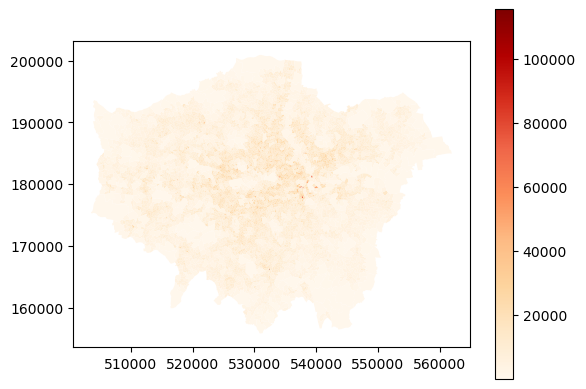

In [15]:
pop_data = pd.read_csv(population / "Pop_LSOA_London.csv")
merged_london_pop = london_full_lsoa.merge(pop_data, left_on='lsoa21cd', right_on='Lower layer Super Output Areas Code', how='left')
merged_london_pop.plot(column='Observation', cmap='OrRd', legend=True)
plt.show()

In [25]:
imd = pd.read_csv(IMD/"LSOA_IMD2025.csv")

london_codes = london_full_lsoa['lsoa21cd']
imd_london_lsoa = imd[imd['LSOA Code'].isin(london_codes)]
imd_london_lsoa.to_csv(processed_data / 'imd_london_lsoa.csv', index=False)

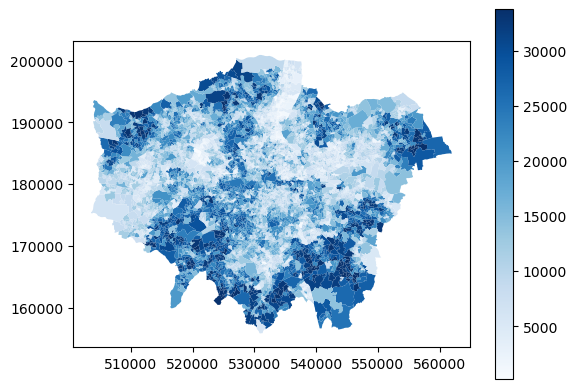

    lsoa21cd        lsoa21nm   msoa21cd       msoa21nm    lad22cd    lad22nm  \
0  E01003912  Southwark 019A  E02000825  Southwark 019  E09000028  Southwark   
1  E01003923  Southwark 017A  E02000823  Southwark 017  E09000028  Southwark   
2  E01003924  Southwark 021E  E02000827  Southwark 021  E09000028  Southwark   
3  E01003925  Southwark 020E  E02000826  Southwark 020  E09000028  Southwark   
4  E01003926  Southwark 021F  E02000827  Southwark 021  E09000028  Southwark   

                                            geometry  \
0  POLYGON ((533471.653 177037.166, 533477.64 177...   
1  POLYGON ((532355 177476, 532345 177471, 532343...   
2  POLYGON ((532427.225 177454.5, 532428.336 1774...   
3  POLYGON ((532944.189 177229.842, 532936.114 17...   
4  POLYGON ((532023.078 177417.796, 532028.968 17...   

  Lower layer Super Output Areas Code Lower layer Super Output Areas  \
0                           E01003912                 Southwark 019A   
1                           E01003923 

In [26]:
merged_london_pop_imd = merged_london_pop.merge(imd_london_lsoa, left_on='lsoa21cd', right_on='LSOA Code', how='left')
merged_london_pop_imd.plot(column='LSOA IMD Ranking', cmap='Blues', legend=True)
plt.show()
print(merged_london_pop_imd.head())

In [27]:
car_ownership_london = pd.read_csv( raw_data /"Car_Ownership/TS045-2021-4-filtered-2026-01-17T23_57_30Z.csv")
carownership_london_wide = car_ownership_london.pivot(index='Lower layer Super Output Areas Code', columns='Car or van availability (5 categories)', values='Observation').reset_index()

# Save the reshaped DataFrame to a CSV file
carownership_london_wide.to_csv(processed_data / 'carownership_london_wide.csv', index=False)

carownership_london_wide['Total_HH'] = carownership_london_wide.iloc[:, 1:6].sum(axis=1)
carownership_london_wide['No_Car_HH'] = carownership_london_wide['No cars or vans in household']/carownership_london_wide['Total_HH']
carownership_london_wide['Low_Car_HH'] = (carownership_london_wide['1 car or van in household'] + carownership_london_wide['No cars or vans in household'])/carownership_london_wide['Total_HH']

carownership_london_wide.columns.name = None
car_wide = carownership_london_wide[['Lower layer Super Output Areas Code', 'No_Car_HH', 'Low_Car_HH']]
print(car_wide.head())

  Lower layer Super Output Areas Code  No_Car_HH  Low_Car_HH
0                           E01000001   0.663082    0.953405
1                           E01000002   0.701456    0.953883
2                           E01000003   0.812193    0.978368
3                           E01000005   0.782881    0.974948
4                           E01000006   0.330325    0.783394


In [28]:
merged_london_pop_imd_car = merged_london_pop_imd.merge(car_wide, left_on='lsoa21cd', right_on='Lower layer Super Output Areas Code', how='left')
print(merged_london_pop_imd_car.shape)

(4994, 21)


In [29]:
PTAL_london = pd.read_csv( raw_data /"PTAL/LSOA_aggregated_PTAL_stats_2023.csv")
PTAL_london_score = PTAL_london[['LSOA21CD', 'MEAN_PTAL_']]
merged_london_pop_imd_car_PTAL = merged_london_pop_imd_car.merge(PTAL_london_score, left_on='lsoa21cd', right_on='LSOA21CD', how='left')

In [30]:
merged_london_pop_imd_car_PTAL = merged_london_pop_imd_car_PTAL.rename(columns={
    'lsoa21cd': 'LSOA_2021',
    'lsoa21nm': 'LSOA_name_2021',
    'msoa21cd': 'MSOA_code',
    'msoa21nm': 'MSOA_name',
    'lad22cd': 'LAD_code',
    'lad22nm': 'LAD_name',
    'Lower layer Super Output Areas Code_x': 'LSOA_code',
    'Lower layer Super Output Areas': 'LSOA_name_todel',
    'Observation': 'Population',
    'GeoPackage Unique ID': 'GPKG_ID',
    'IMD Decile': 'IMD_Decile',
    'LSOA IMD Ranking': 'IMD_Ranking',
    'Shape__Area': 'Shape_Area',
    'Shape__Length': 'Shape_Length',
    'Lower layer Super Output Areas Code_y': 'LSOA_del',
     'MEAN_PTAL_': 'PTAL'
})

merged_london_pop_imd_car_PTAL = merged_london_pop_imd_car_PTAL.drop(
    columns=[
        c for c in merged_london_pop_imd_car_PTAL.columns
        if ('LSOA' in c.upper()) and (c not in ['LSOA_2021', 'LSOA_name_2021'])
    ]
)

merged_london_pop_imd_car_PTAL.drop(columns='fid', inplace=True, errors='ignore')
print(merged_london_pop_imd_car_PTAL.shape)



(4994, 16)


In [31]:
merged_london_pop_imd_car_PTAL.to_file(processed_data / '00_full_london_basic_data.gpkg', driver='GPKG')